# Bayesian Uncertainty Minimization

This demo shows how to minimize the uncertainty of a simple 1D function using Bayesian optimization with a GPR as the surrogate model. The GPR can use derivative information to aid in the regression.

In [1]:
import sys 
import numpy as np
import matplotlib.pyplot as plt
import time
import copy

sys.path.append("../..")
import gpder 
from gpder import UncertaintyOptimization

from utils import plot_gpr_evolution, plot_gpr_iterloss

We regress the same function as in the 'Gaussian Process' demo, but instead of randomly selecting training points for the GPR, we rely on a Bayesian optimization to find the training points which minimize the uncertainty of the model.

In [2]:
def F(X, s=0.1):
    noise = s * np.random.uniform(-1, 1)
    return X * np.sin(4*np.pi * X**2) + s

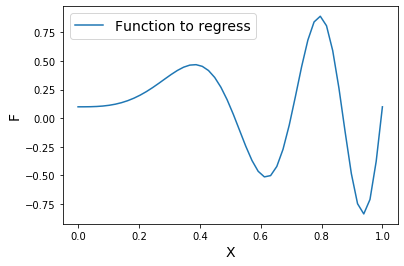

In [3]:
np.random.seed(1)

X_lower = 0 
X_upper = 1
X_star = np.linspace(X_lower, X_upper, 50)
y_star = F(X_star)

plt.plot(X_star, y_star, label='Function to regress')
plt.xlabel("X", fontsize=14)
plt.ylabel("F", fontsize=14)
plt.legend(fontsize=14)
plt.show()

## Regular GPR

We begin by minimizing the uncertainty of a regular GPR regression.

To kick off the search, we begin with one randomly selected training point. With every iteration, we sample the point which is predicted to minimize the uncertainty. That is, the nth point is chosen to minimize the uncertainty of the model with n-training points.

In [4]:
from gpder.bayes.minimizers import hybrid_minimizer

In [5]:
def minimizer(fun, bounds):
    return hybrid_minimizer(fun, bounds, 
                            N_rand=20, 
                            N_brute=10)

| Iter | X         | Target    | MSE val   | Uncert val|
| 1    | 0.696469  | -0.029909 | 0.134436  | 2.396539  |
| 2    | 0.286139  | 0.345142  | 0.134436  | 2.396539  |
| 3    | 0.226851  | 0.236688  | 0.134436  | 2.396539  |
| 4    | 0.551315  | -0.245775 | 0.134436  | 2.396539  |
| 5    | 0.719469  | 0.258144  | 0.134436  | 2.396539  |
| 6    | 1.003637  | 0.191767  | 0.146145  | 2.152343  |
| 7    | 0.660025  | -0.377527 | 0.174527  | 3.445594  |
| 8    | 0.240156  | 0.259213  | 0.087946  | 2.353422  |
| 9    | 0.000000  | 0.100000  | 0.095307  | 1.758539  |
| 10   | 0.434046  | 0.403442  | 0.166325  | 3.452268  |
| 11   | 0.178016  | 0.169031  | 0.165092  | 3.141585  |
| 12   | 0.561835  | -0.312728 | 0.232288  | 0.301100  |
| 13   | 0.996242  | 0.006229  | 0.063320  | 1.400649  |
| 14   | 0.964141  | -0.646209 | 0.006579  | 0.206423  |
| 15   | 0.002703  | 0.100000  | 0.006795  | 0.105816  |


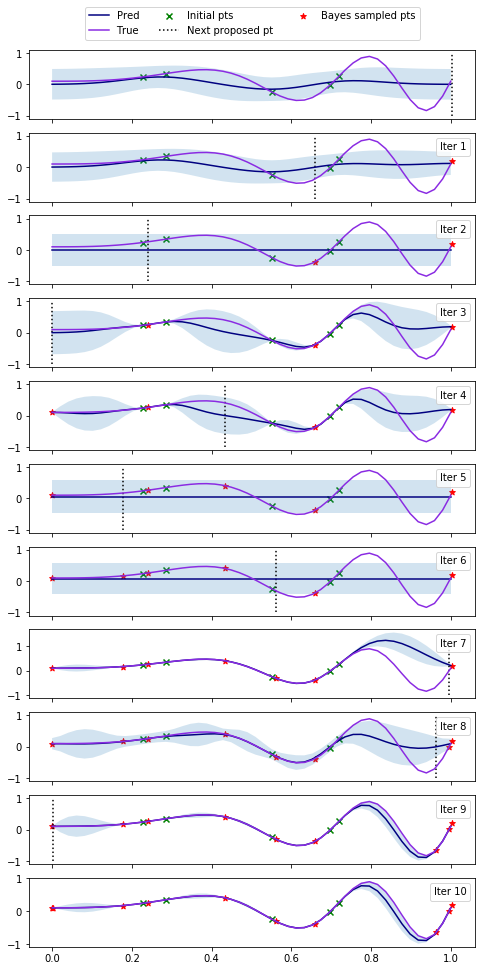

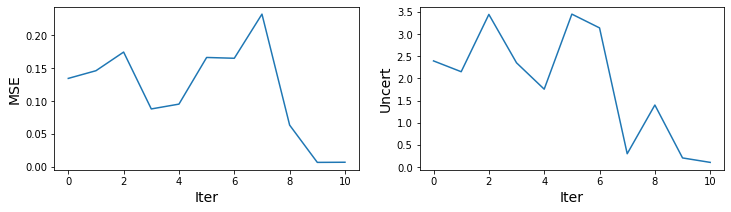

In [6]:
bayes = UncertaintyOptimization(fun=F,
                                verbose=True,
                                param_bounds={'X': (0, 1)},
                                ignore_convergence_warnings=True,
                                random_state=123)
bayes.minimize_uncertainty(nrand_train=5,
                           minimizer=minimizer,
                           params_val=X_star.reshape(-1, 1),
                           niters=10,
                           minimizer_restarts=5,
                           gp_optimizer_restarts=10)

plot_gpr_evolution(bayes=copy.deepcopy(bayes))
plot_gpr_iterloss(bayes=copy.deepcopy(bayes))

## Derivative-enhanced GPR

In [7]:
def dF(X, s=0.1):
    noise = s * np.random.uniform(-1, 1)
    return np.sin(4*np.pi * X**2) + X * np.cos(4*np.pi * X**2) * (8*np.pi * X) + s

| Iter | X         | Target    | MSE val   | Uncert val|
| 1    | 0.696469  | -0.029909 | 0.177286  | 2.304318  |
| 2    | 0.286139  | 0.345142  | 0.177286  | 2.304318  |
| 3    | 0.226851  | 0.236688  | 0.177286  | 2.304318  |
| 4    | 0.551315  | -0.245775 | 0.177286  | 2.304318  |
| 5    | 0.719469  | 0.258144  | 0.177286  | 2.304318  |
| 6    | 1.003095  | 0.178073  | 0.007138  | 4.058680  |
| 7    | 0.000000  | 0.100000  | 0.006306  | 1.078392  |
| 8    | 0.486480  | 0.181151  | 0.005117  | 0.264535  |
| 9    | 0.842983  | 0.500334  | 0.000479  | 0.023942  |
| 10   | 0.370294  | 0.466009  | 0.000352  | 0.018763  |
| 11   | 0.957239  | -0.731154 | 0.000063  | 0.050092  |
| 12   | 0.109966  | 0.116646  | 0.000003  | 0.001273  |
| 13   | 0.842974  | 0.500481  | 0.000016  | 0.002987  |
| 14   | 0.536443  | -0.145166 | 0.000003  | 0.001047  |
| 15   | 0.813844  | 0.825870  | 0.000003  | 0.000959  |


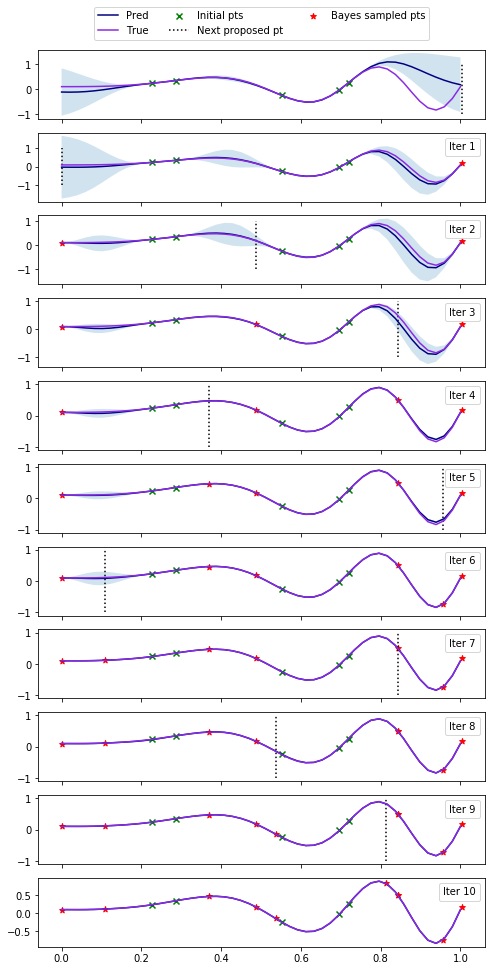

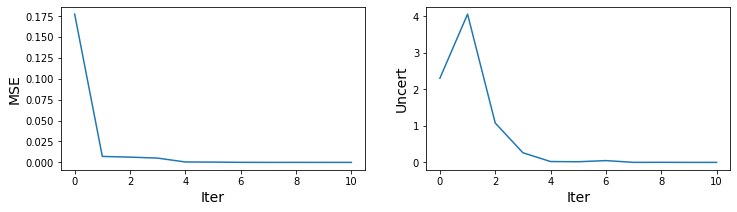

In [8]:
bayes = UncertaintyOptimization(fun=F,
                                dfun=dF,
                                verbose=True,
                                param_bounds={'X': (0, 1)},
                                ignore_convergence_warnings=True,
                                random_state=123)

bayes.minimize_uncertainty(nrand_train=5,
                           minimizer=minimizer,
                           params_val=X_star.reshape(-1, 1),
                           niters=10,
                           minimizer_restarts=5,
                           gp_optimizer_restarts=10)

plot_gpr_evolution(bayes=copy.deepcopy(bayes))
plot_gpr_iterloss(bayes=copy.deepcopy(bayes))